# CIFAKE: Image Classification and Explainable Identification of AI-Generated Synthetic Images

This project classifies images as Real or AI-Generated using a deep learning model.

In [2]:
!pip install -q kaggle

In [3]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fafarhan91","key":"660276341ec9989158059e988c0e4e17"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images
!unzip -q cifake-real-and-ai-generated-synthetic-images.zip -d cifake_dataset

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:00<00:00, 172MB/s]



In [6]:
import os

for root, dirs, files in os.walk("cifake_dataset"):
    print(root, len(files))

cifake_dataset 0
cifake_dataset/train 0
cifake_dataset/train/REAL 50000
cifake_dataset/train/FAKE 50000
cifake_dataset/test 0
cifake_dataset/test/REAL 10000
cifake_dataset/test/FAKE 10000


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

In [8]:
train_dir = "cifake_dataset/train"
test_dir = "cifake_dataset/test"

img_size = (32, 32)
batch_size = 64

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

class_names = train_data.class_names
print("Classes:", class_names)

Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
Classes: ['FAKE', 'REAL']


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_data = test_data.cache().prefetch(buffer_size=AUTOTUNE)

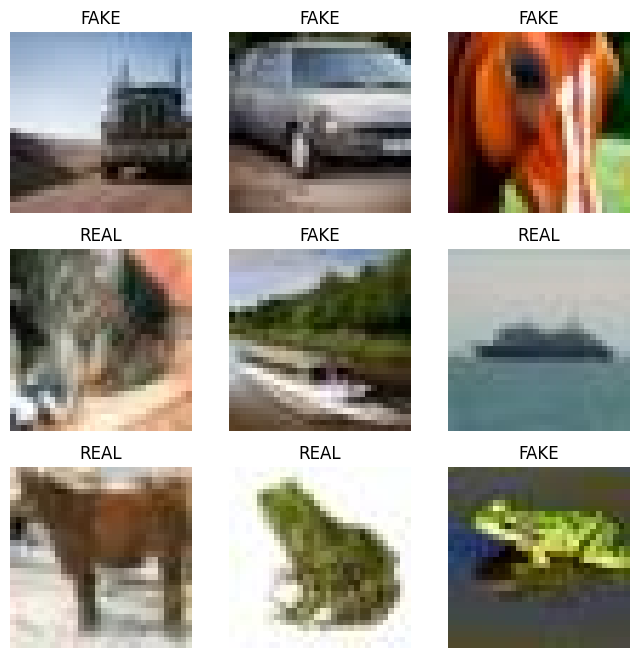

In [10]:
plt.figure(figsize=(8, 8))

for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label = int(labels[i].numpy()[0])
        plt.title(class_names[label])
        plt.axis("off")

In [11]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=3
)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 153s 88ms/step - accuracy: 0.8465 - loss: 0.3456 - val_accuracy: 0.8959 - val_loss: 0.2516
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 128s 82ms/step - accuracy: 0.9086 - loss: 0.2267 - val_accuracy: 0.9108 - val_loss: 0.2232
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 124s 79ms/step - accuracy: 0.9252 - loss: 0.1910 - val_accuracy: 0.9253 - val_loss: 0.1915


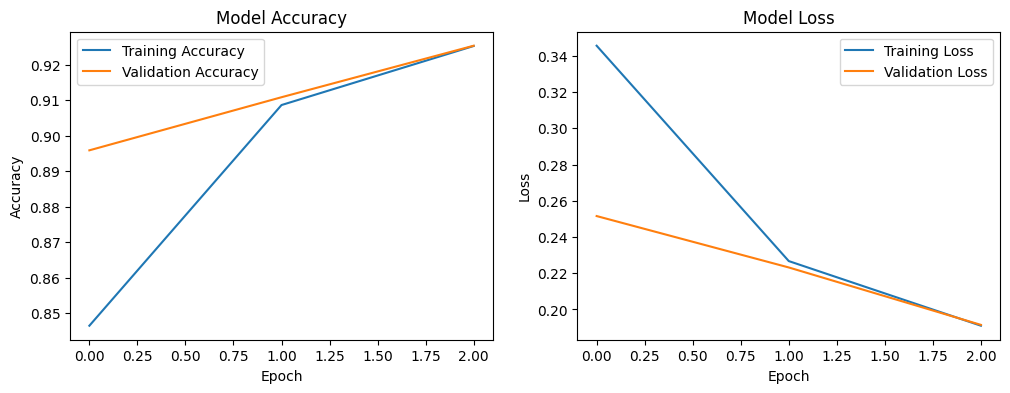

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [14]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", round(accuracy * 100, 2), "%")
print("Test Loss:", round(loss, 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9253 - loss: 0.1915
Test Accuracy: 92.53 %
Test Loss: 0.1915


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step


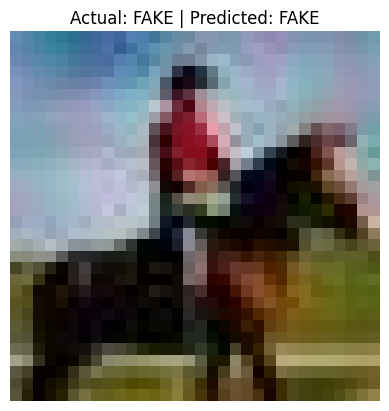

Prediction Score: 0.02088694


In [15]:
for images, labels in test_data.take(1):
    image = images[0]
    actual_label = int(labels[0].numpy()[0])

    prediction = model.predict(tf.expand_dims(image, axis=0))[0][0]
    predicted_label = 1 if prediction >= 0.5 else 0

    plt.imshow(image.numpy().astype("uint8"))
    plt.axis("off")
    plt.title(
        f"Actual: {class_names[actual_label]} | Predicted: {class_names[predicted_label]}"
    )
    plt.show()

    print("Prediction Score:", prediction)

In [16]:
model.save("cifake_model.h5")
print("Model saved successfully.")

Model saved successfully.


## Conclusion

This project successfully classifies images as Real or AI-Generated using a CNN model.  
The model was trained and tested on the CIFAKE dataset.  
The output shows prediction results and model accuracy.